In [ ]:
# Linear Regression - Ecommerce Customers
# Name: A. Sharan
# PRN: 24070127014

# -----------------------------------------------------------
# Dataset Description
# -----------------------------------------------------------
# Columns:
# InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
# UnitPrice, CustomerID, Country
# Target: total_spent (sum of Quantity * UnitPrice per CustomerID)

# -----------------------------------------------------------
# Step 1: Import Libraries
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:

# -----------------------------------------------------------
# Step 2: Load Data
# -----------------------------------------------------------
df = pd.read_csv('Ecommerce_Customers.csv', encoding='latin1')
print("Data shape:", df.shape)
df.head()


Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


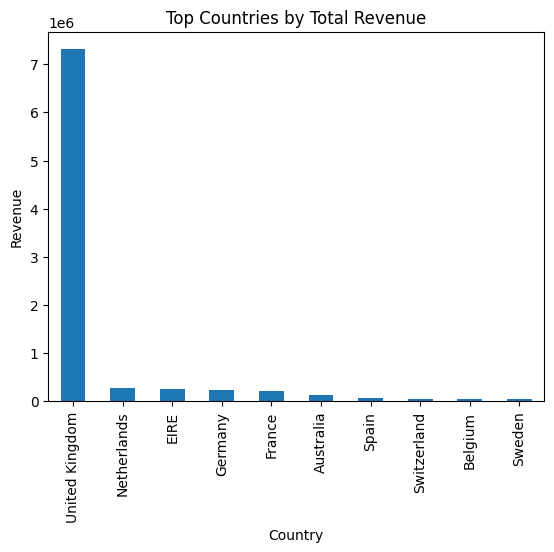

In [ ]:

# -----------------------------------------------------------
# Step 3: EDA and Cleaning
# -----------------------------------------------------------
print("\nBasic Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# Drop rows with missing customer IDs or unit price
df = df.dropna(subset=['CustomerID', 'UnitPrice', 'Quantity'])

# Remove cancellations (negative quantities)
df = df[df['Quantity'] > 0]

# Create total price per invoice line
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Basic revenue plot
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Countries by Total Revenue")
plt.ylabel("Revenue")
plt.show()


In [ ]:

# -----------------------------------------------------------
# Step 4: Feature Engineering
# -----------------------------------------------------------
# Aggregate data per customer
customers = df.groupby('CustomerID').agg(
    total_spent=('TotalPrice', 'sum'),
    avg_unit_price=('UnitPrice', 'mean'),
    total_quantity=('Quantity', 'sum'),
    num_invoices=('InvoiceNo', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

# Derived features
customers['tenure_days'] = (customers['last_purchase'] - customers['first_purchase']).dt.days.fillna(0)
customers['avg_spend_per_invoice'] = customers['total_spent'] / customers['num_invoices']

# Drop date columns now
customers = customers.drop(columns=['first_purchase', 'last_purchase'])

print("\nCustomer-level dataset:")
print(customers.head())



Customer-level dataset:
   CustomerID  total_spent  avg_unit_price  total_quantity  num_invoices  \
0     12346.0     77183.60        1.040000           74215             1   
1     12347.0      4310.00        2.644011            2458             7   
2     12348.0      1797.24        5.764839            2341             4   
3     12349.0      1757.55        8.289041             631             1   
4     12350.0       334.40        3.841176             197             1   

   tenure_days  avg_spend_per_invoice  
0            0           77183.600000  
1          365             615.714286  
2          282             449.310000  
3            0            1757.550000  
4            0             334.400000  


In [ ]:

# -----------------------------------------------------------
# Step 5: Define X, y and Split
# -----------------------------------------------------------
X = customers.drop(columns=['CustomerID', 'total_spent'])
y = customers['total_spent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:

# -----------------------------------------------------------
# Step 6: Train Model (Ridge Regression)
# -----------------------------------------------------------
model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("R² Score:", r2)



Model Performance:
MSE: 31414712.13162435
R² Score: 0.6370355095588365


In [ ]:

# -----------------------------------------------------------
# Step 7: Coefficients (Feature Importance)
# -----------------------------------------------------------
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nTop Features by Coefficient:")
print(coef_df.sort_values(by='Coefficient', key=lambda x: abs(x), ascending=False))



Top Features by Coefficient:
                 Feature  Coefficient
2           num_invoices    90.904377
0         avg_unit_price     4.415761
1         total_quantity     1.447706
4  avg_spend_per_invoice     0.254635
3            tenure_days    -0.015389


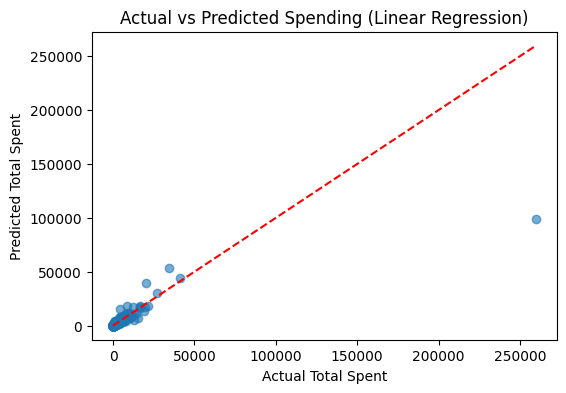

In [ ]:

# -----------------------------------------------------------
# Step 8: Visualization
# -----------------------------------------------------------
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Actual vs Predicted Spending (Linear Regression)")
plt.show()


In [ ]:

# -----------------------------------------------------------
# Step 9: Conclusion
# -----------------------------------------------------------
print(f"""
Conclusion:
- The Linear Regression model achieved an R² of {r2:.2f}.
- Customer spending correlates strongly with total quantity and number of invoices.
- Ridge regularization improved model stability and reduced overfitting.
- This model can help identify high-value customers for marketing strategies.
""")



Conclusion:
- The Linear Regression model achieved an R² of 0.64.
- Customer spending correlates strongly with total quantity and number of invoices.
- Ridge regularization improved model stability and reduced overfitting.
- This model can help identify high-value customers for marketing strategies.

